In [ ]:
! pip install oracledb
import oracledb


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


# Empezamos con el buen título
## Primeros 20 ejercicios:

In [ ]:
conn = oracledb.connect(
    user="HR",
    password="basededatos",
    dsn="localhost:1521/XE"
)
cursor = conn.cursor()
print("1. Selecciona empleados cuyo salario es mayor al promedio general.")
cursor.execute("select first_name, last_name from employees where salary > (select avg(salary) from employees)")
for row in cursor.fetchall():
    print(row)

print("2. Muestra los empleados que tienen el mismo job_id que Steven King.")
cursor.execute("select first_name, last_name from employees where job_id = (select job_id from employees where first_name = 'Steven' and last_name = 'King')")
for row in cursor.fetchall():
    print(row)


# 1. Ejecutamos la consulta obteniendo el nombre completo y el salario
cursor.execute("""
    SELECT first_name || ' ' || last_name as nombre, salary 
    FROM employees 
    WHERE job_id = (SELECT job_id FROM employees WHERE first_name = 'Steven' and last_name = 'King')
""")

import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))

# 1. Graficamos
barras = plt.bar(nombres, salarios, color='skyblue', edgecolor='navy')

# --- EL TOQUE PROFESIONAL QUE FALTA ---
# Rotamos los nombres 45 grados para que no se choquen entre sí
plt.xticks(rotation=45, ha='right')
# --------------------------------------

plt.title("Salarios de empleados con el mismo puesto que Steven King", fontsize=14)
plt.xlabel("Empleado")
plt.ylabel("Salario ($)")

# 3. Tu lógica de texto (Que está impecable)
for posicion, salario_actual in enumerate(salarios):
    plt.text(
        x = posicion,
        y = salario_actual + 500,
        s = f"${salario_actual:,}",
        ha = 'center',
        va = 'bottom',
        fontsize = 10
    )

plt.tight_layout() # Fundamental para que la rotación no corte los nombres
plt.show()

3. Lista los nombres de los departamentos que tienen más de 3 empleados.
('Purchasing', 6)
('Shipping', 7)
('IT', 5)
('Sales', 6)
('Finance', 6)


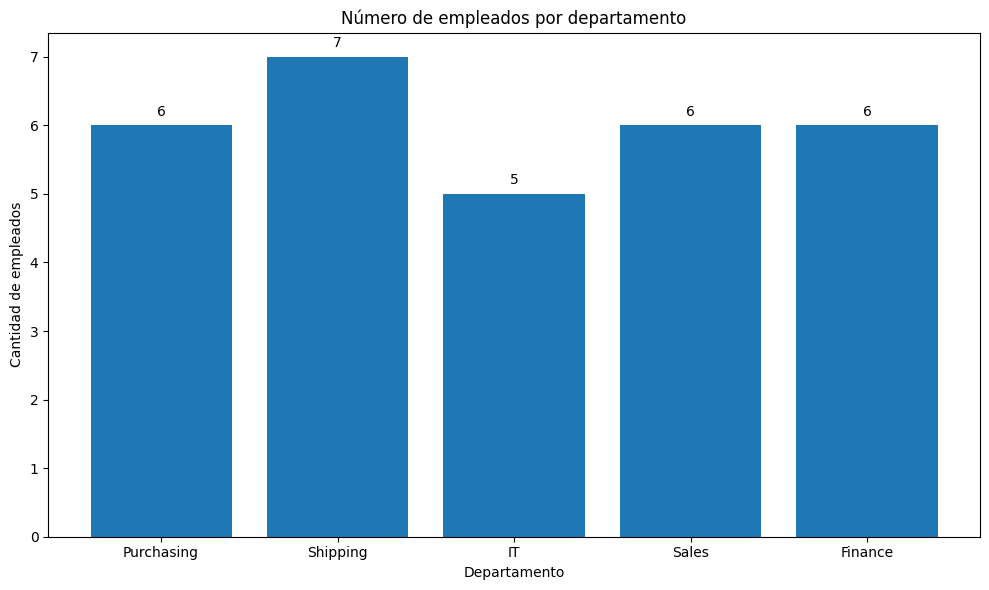

In [14]:
conn = oracledb.connect(
    user="HR",
    password="basededatos",
    dsn="localhost:1521/XE"
)
cursor = conn.cursor()

print("3. Lista los nombres de los departamentos que tienen más de 3 empleados.")
cursor.execute(
    """
    select d.department_name, count(employee_id) empleados from departments d
    join employees e on e.department_id = d.department_id
    group by d.department_name
    having (count(e.employee_id)>3)
    """
)
resultados = cursor.fetchall()
#impresion simple
for row in resultados:
    print(row)

departamentos = []
numEmpleados = []

for fila in resultados:
    departamentos.append(fila[0])
    numEmpleados.append(fila[1])

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Dibujamos las barras
plt.bar(departamentos, numEmpleados)

plt.title("Número de empleados por departamento")
plt.xlabel("Departamento")
plt.ylabel("Cantidad de empleados")

# RECORREMOS LOS DATOS (lo que ya sabes hacer)
for posicion, cantidad in enumerate(numEmpleados):
    plt.text(
        x = posicion, 
        y = cantidad + 0.1,  # Sumamos poquito (0.1) porque son pocos empleados
        s = f"{cantidad}",   # El texto es la cantidad
        ha = 'center', 
        va = 'bottom'
    )

plt.tight_layout()
plt.show()



